In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(18, 22))
gs = GridSpec(4, 2, figure=fig)

<Figure size 1800x2200 with 0 Axes>

In [55]:
df = pd.read_csv("/Users/eugene_kuj/PycharmProjects/DS_lab/data/merged_v5.csv")

df.head()

,region_id,time,alarm,neighbor_alarms_count,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day
0,2,2022-03-28 00:00:00+03:00,0,0,0.4,-2.2,43.82,-10.5,0.0,0.0,0,7.6,314.0,1029.0,24.1,2.0,0.0,0,13,5,0,0,4,4,0,0,0,0,0,0,5,5,5,4,0,86,289,-3,0,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
1,2,2022-03-28 01:00:00+03:00,0,0,-0.1,-2.5,45.43,-10.5,0.0,0.0,0,6.8,308.6,1029.0,24.1,4.2,0.0,0,8,2,0,0,3,3,0,0,0,0,0,0,1,1,1,4,0,45,285,-3,1,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
2,2,2022-03-28 02:00:00+03:00,0,0,-0.6,-2.3,47.87,-10.3,0.0,0.0,0,5.0,305.7,1029.0,24.1,3.1,0.0,0,7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,28,269,-2,2,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
3,2,2022-03-28 03:00:00+03:00,0,0,-1.1,-1.1,51.24,-9.9,0.0,0.0,0,4.0,289.8,1029.0,24.1,1.8,0.0,0,11,10,0,0,0,0,2,0,2,0,0,0,9,9,9,0,2,26,275,10,3,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
4,2,2022-03-28 04:00:00+03:00,0,0,-1.4,-1.4,52.80,-9.8,0.0,0.0,0,3.6,245.2,1029.0,24.1,0.0,0.0,0,9,1,0,0,6,6,2,0,2,0,0,0,1,1,2,6,2,27,283,-9,4,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28


In [25]:
df.shape

(734233, 69)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 734233 entries, 0 to 734232
Data columns (total 69 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   region_id                  734233 non-null  int64  
 1   time                       734233 non-null  str    
 2   alarm                      734233 non-null  int64  
 3   neighbor_alarms_count      734233 non-null  int64  
 4   hour_temp                  734233 non-null  float64
 5   hour_feelslike             734233 non-null  float64
 6   hour_humidity              734233 non-null  float64
 7   hour_dew                   734233 non-null  float64
 8   hour_precip                734233 non-null  float64
 9   hour_precipprob            734233 non-null  float64
 10  hour_preciptype            734233 non-null  int64  
 11  hour_windspeed             734233 non-null  float64
 12  hour_winddir               734233 non-null  float64
 13  hour_pressure              734233 non-nu

# Dataset містить часові ряди з погодними, текстовими та поведінковими ознаками.
Цільова змінна: alarm (0 або 1).

In [29]:
# %%
df['alarm'].value_counts(normalize=True)

alarm
0    0.776831
1    0.223169
Name: proportion, dtype: float64

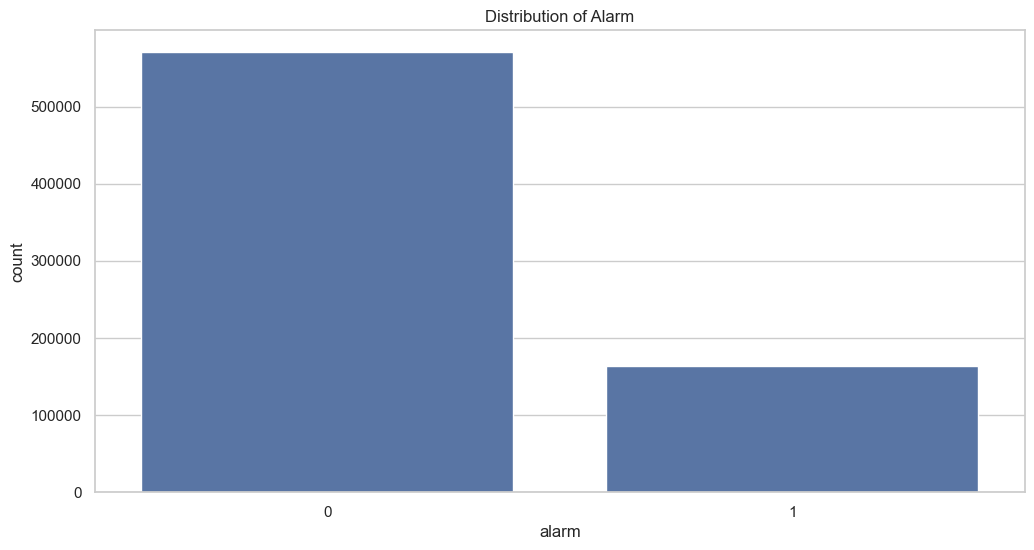

In [31]:
sns.countplot(x='alarm', data=df)
plt.title("Distribution of Alarm")
plt.show()

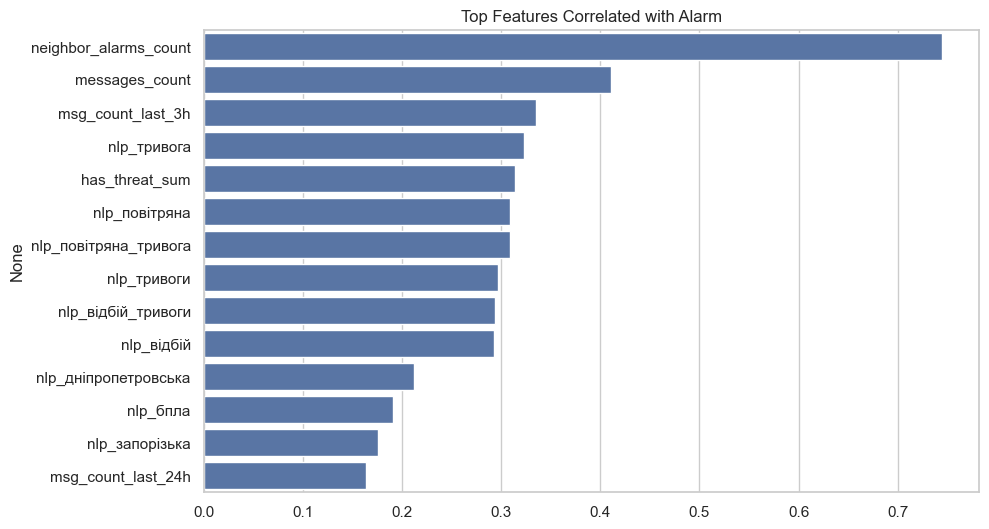

In [32]:
corr = df.corr(numeric_only=True)

alarm_corr = corr['alarm'].abs().sort_values(ascending=False)[1:15]

plt.figure(figsize=(10,6))
sns.barplot(x=alarm_corr.values, y=alarm_corr.index)
plt.title("Top Features Correlated with Alarm")
plt.show()

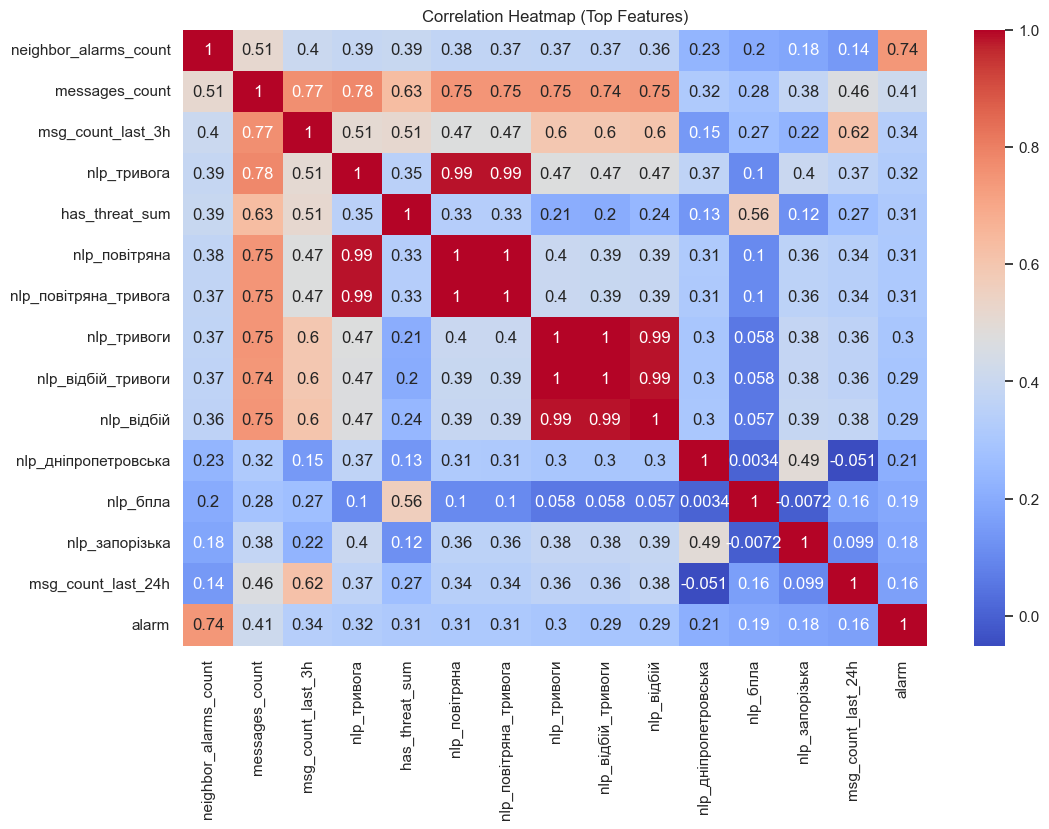

In [33]:
top_features = alarm_corr.index.tolist() + ['alarm']

plt.figure(figsize=(12,8))
sns.heatmap(df[top_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Top Features)")
plt.show()

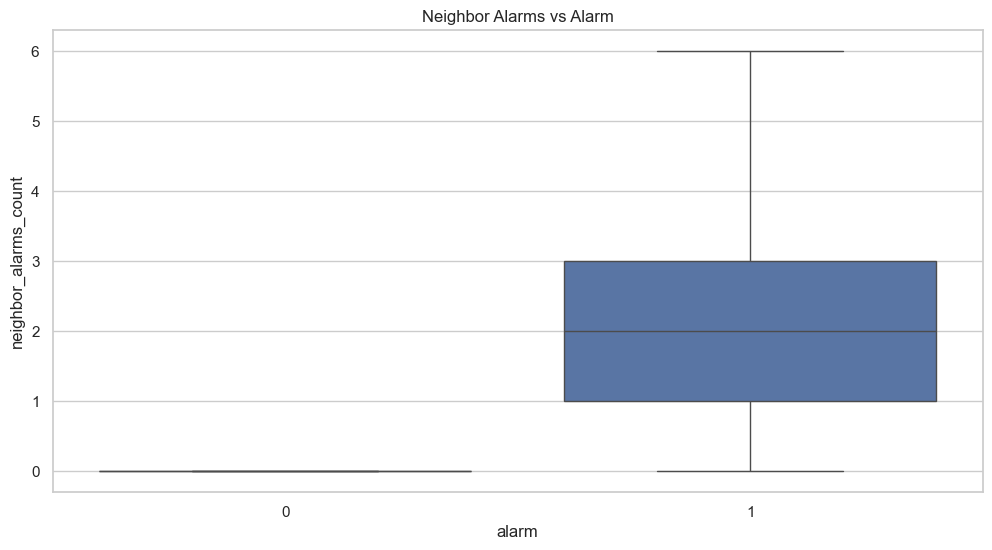

In [35]:
sns.boxplot(x='alarm', y='neighbor_alarms_count', data=df)
plt.title("Neighbor Alarms vs Alarm")
plt.show()

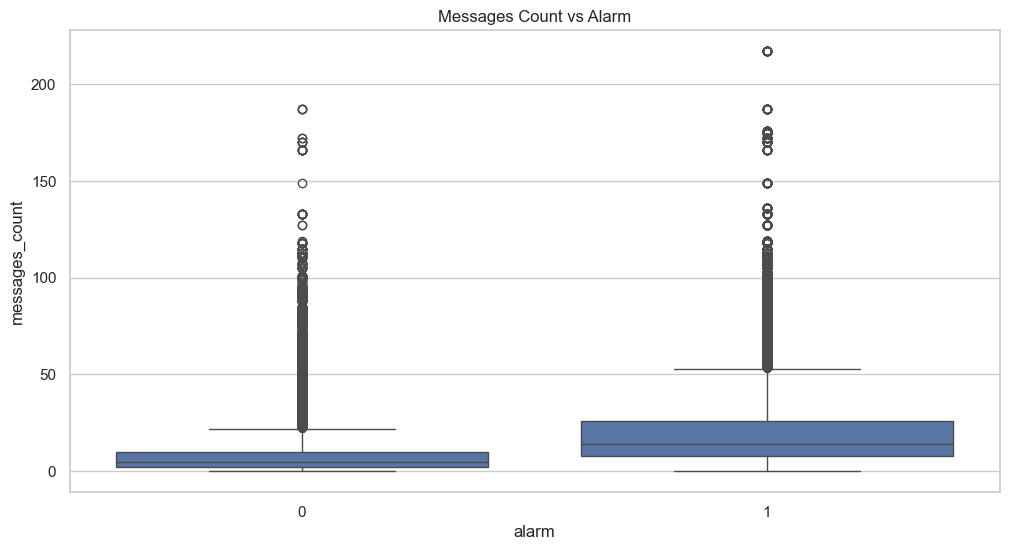

In [37]:
sns.boxplot(x='alarm', y='messages_count', data=df)
plt.title("Messages Count vs Alarm")
plt.show()

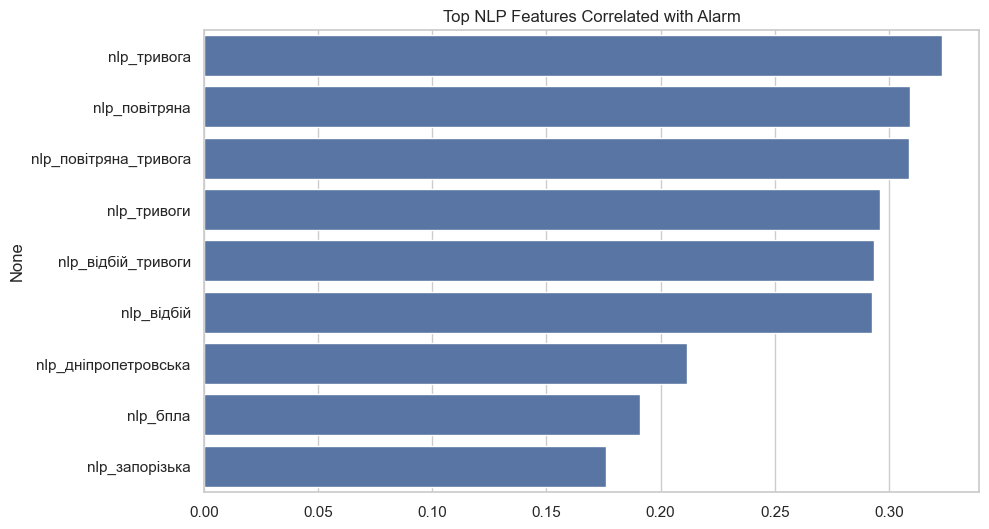

In [38]:
# %%
nlp_cols = [col for col in df.columns if col.startswith('nlp_')]

nlp_corr = df[nlp_cols + ['alarm']].corr()['alarm'].abs().sort_values(ascending=False)[1:10]

plt.figure(figsize=(10,6))
sns.barplot(x=nlp_corr.values, y=nlp_corr.index)
plt.title("Top NLP Features Correlated with Alarm")
plt.show()

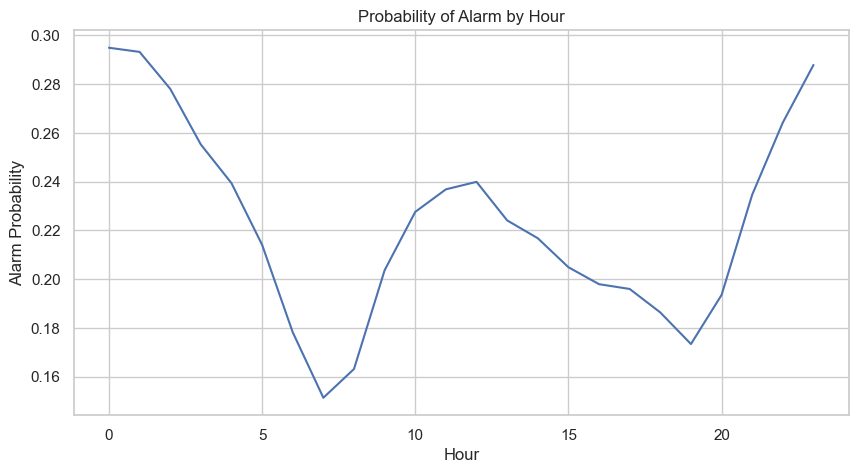

In [40]:
hour_alarm = df.groupby('hour_of_day')['alarm'].mean()

plt.figure(figsize=(10,5))
hour_alarm.plot()
plt.title("Probability of Alarm by Hour")
plt.xlabel("Hour")
plt.ylabel("Alarm Probability")
plt.show()

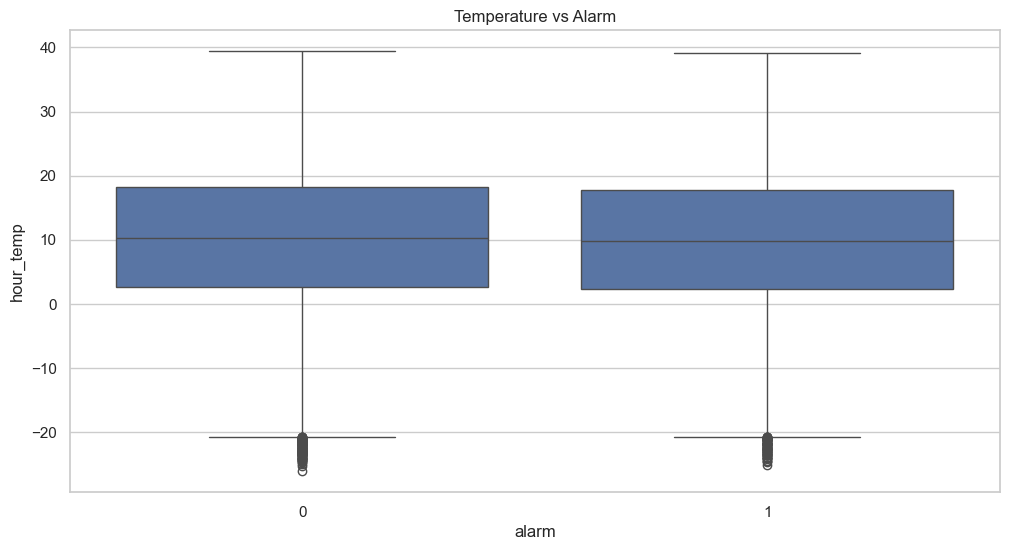

In [52]:
sns.boxplot(x='alarm', y='hour_temp', data=df)
plt.title("Temperature vs Alarm")
plt.show()

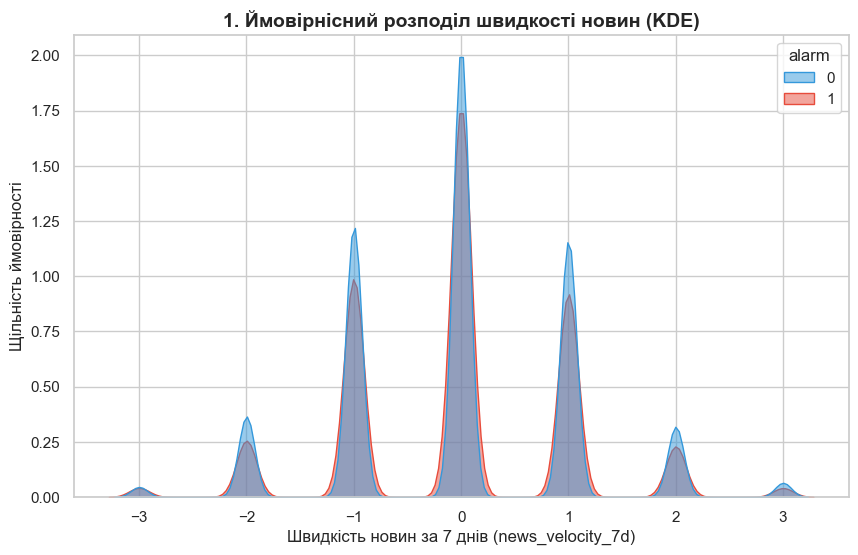

In [68]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='news_velocity_7d', hue='alarm', fill=True, common_norm=False, 
            palette=['#3498db', '#e74c3c'], alpha=0.5)

plt.title('1. Ймовірнісний розподіл швидкості новин (KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Швидкість новин за 7 днів (news_velocity_7d)')
plt.ylabel('Щільність ймовірності')
plt.show()

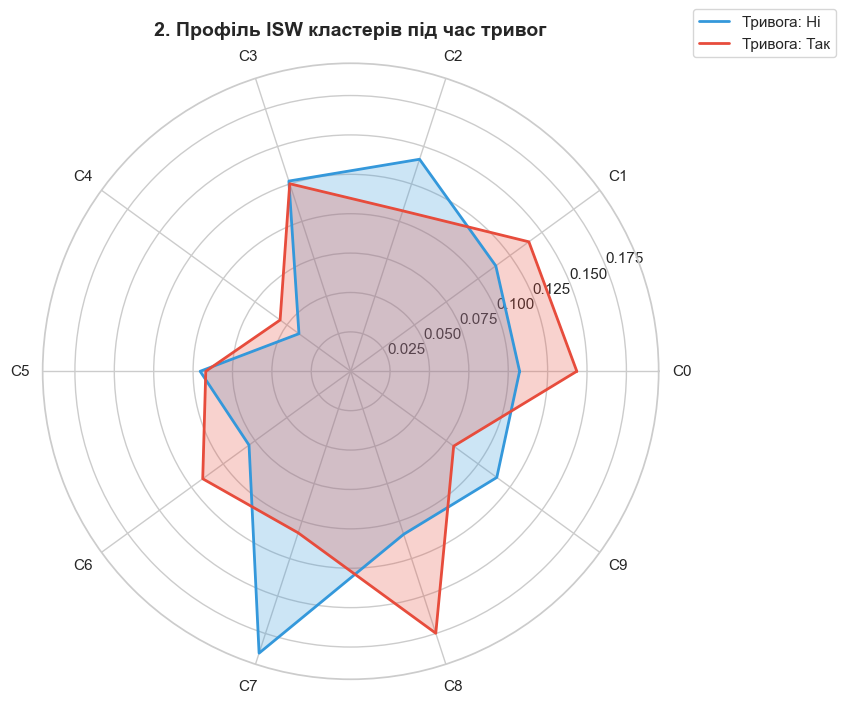

In [69]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Відбираємо колонки кластерів
isw_cols = [f'isw_cluster_{i}' for i in range(10)]
isw_means = df.groupby('alarm')[isw_cols].mean()

angles = np.linspace(0, 2 * np.pi, len(isw_cols), endpoint=False).tolist()
angles += angles[:1] # замикаємо коло

for i, row in isw_means.iterrows():
    values = row.tolist()
    values += values[:1]
    label = 'Тривога: Так' if i == 1 else 'Тривога: Ні'
    color = '#e74c3c' if i == 1 else '#3498db'
    ax.plot(angles, values, label=label, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f'C{i}' for i in range(10)])
plt.title('2. Профіль ISW кластерів під час тривог', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

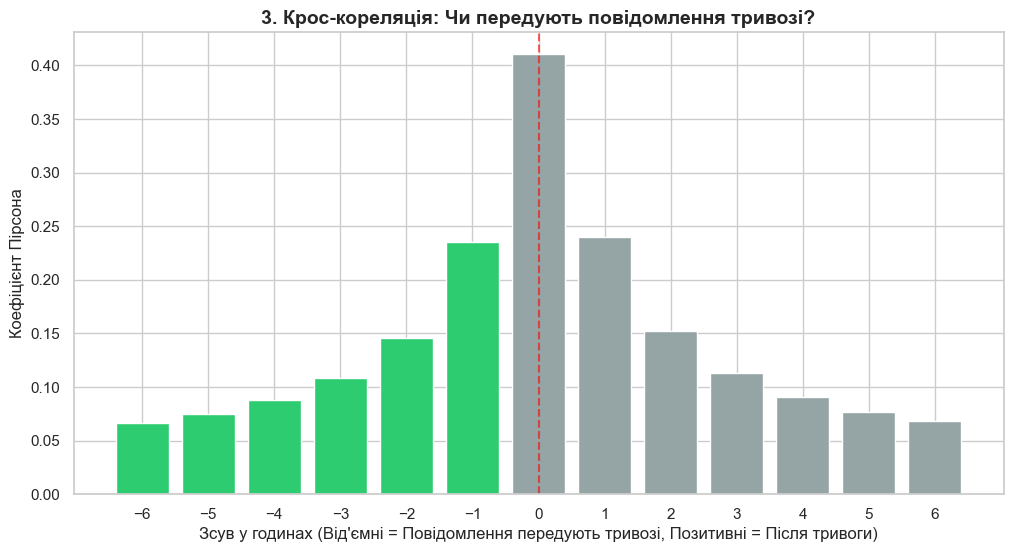

In [70]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# Рахуємо кореляцію із зсувом від -6 до +6 годин
lags = range(-6, 7)
cross_corr = [df['messages_count'].corr(df['alarm'].shift(lag)) for lag in lags]

# Зелений колір для "до тривоги" (predictive), сірий для "після" (reactive)
colors = np.where(np.array(lags) < 0, '#2ecc71', '#95a5a6')

plt.bar(lags, cross_corr, color=colors)
plt.axvline(0, color='red', linestyle='--', alpha=0.6)

plt.title('3. Крос-кореляція: Чи передують повідомлення тривозі?', fontsize=14, fontweight='bold')
plt.xlabel('Зсув у годинах (Від\'ємні = Повідомлення передують тривозі, Позитивні = Після тривоги)')
plt.ylabel('Коефіцієнт Пірсона')
plt.xticks(lags)
plt.show()

/var/folders/y4/w7fytwyn5_sc1g1w2sxgj15c0000gn/T/ipykernel_55048/2485048468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='alarm', y='threat_diff_1h', palette='muted', inner="quartile")


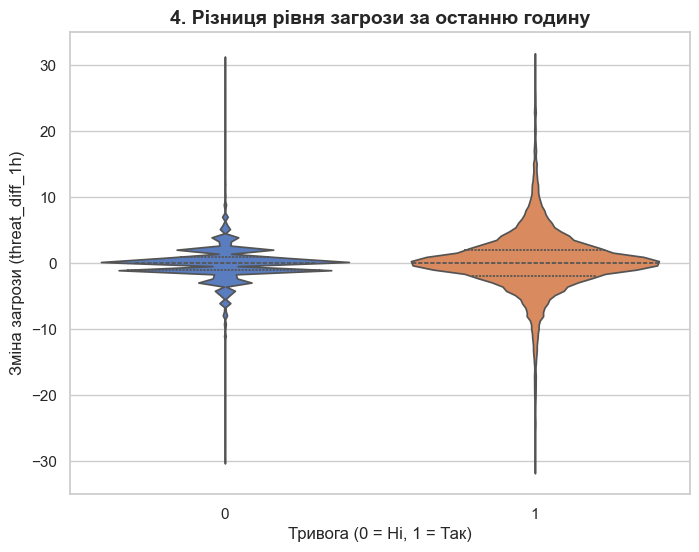

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='alarm', y='threat_diff_1h', palette='muted', inner="quartile")

plt.title('4. Різниця рівня загрози за останню годину', fontsize=14, fontweight='bold')
plt.xlabel('Тривога (0 = Ні, 1 = Так)')
plt.ylabel('Зміна загрози (threat_diff_1h)')
plt.show()

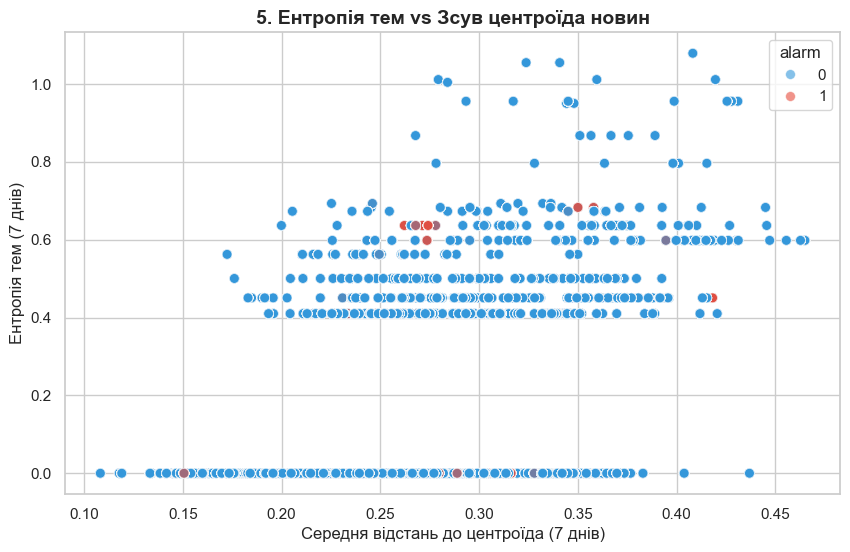

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_dist_centroid_7d', y='topic_entropy_7d', hue='alarm', 
                palette=['#3498db', '#e74c3c'], alpha=0.6, s=50)

plt.title('5. Ентропія тем vs Зсув центроїда новин', fontsize=14, fontweight='bold')
plt.xlabel('Середня відстань до центроїда (7 днів)')
plt.ylabel('Ентропія тем (7 днів)')
plt.show()

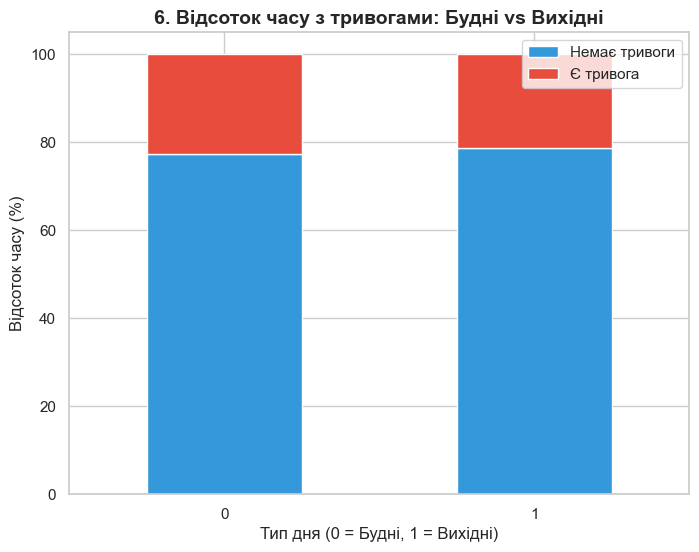

In [75]:
import matplotlib.pyplot as plt

# Підготовка даних для відсоткового стеку
weekend_alarm = df.groupby(['is_weekend', 'alarm']).size().unstack()
weekend_alarm_pct = weekend_alarm.div(weekend_alarm.sum(axis=1), axis=0) * 100

# Побудова графіка
ax = weekend_alarm_pct.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], figsize=(8, 6))

plt.title('6. Відсоток часу з тривогами: Будні vs Вихідні', fontsize=14, fontweight='bold')
plt.xlabel('Тип дня (0 = Будні, 1 = Вихідні)')
plt.ylabel('Відсоток часу (%)')
plt.legend(['Немає тривоги', 'Є тривога'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

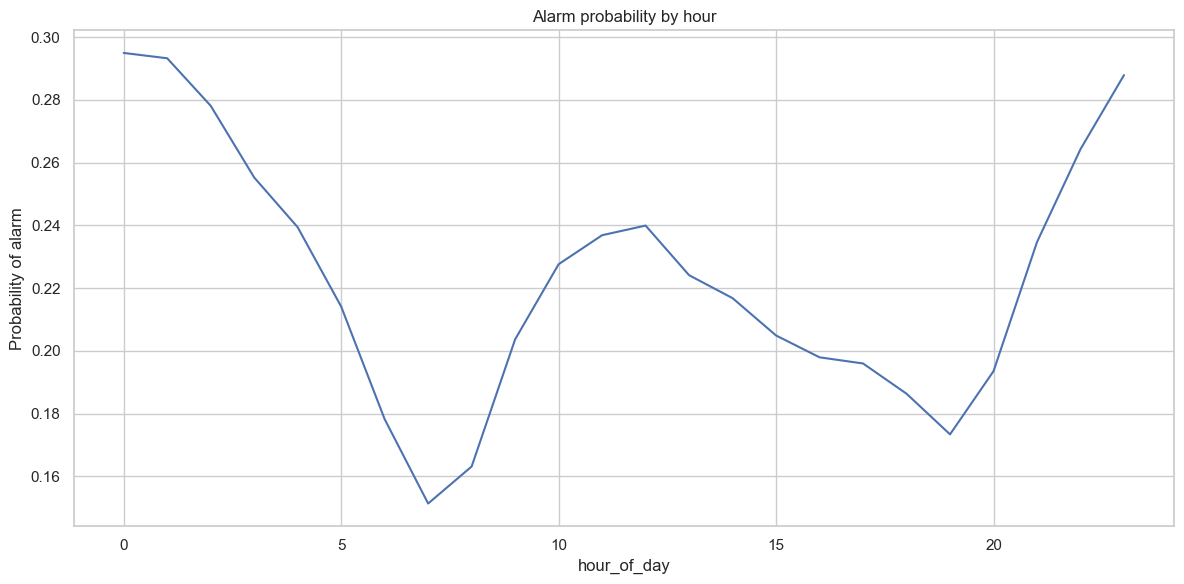

In [20]:
plt.figure()
df.groupby("hour_of_day")["alarm"].mean().plot()
plt.xlabel("hour_of_day")
plt.ylabel("Probability of alarm")
plt.title("Alarm probability by hour")
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю для красивих графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Завантажте ваш файл (замініть шлях на ваш, якщо потрібно)
df = pd.read_csv("/Users/eugene_kuj/PycharmProjects/DS_lab/data/merged_v5.csv")

# Перевіримо, що колонка alarm є числовою
df['alarm'] = df['alarm'].astype(int)

/var/folders/y4/w7fytwyn5_sc1g1w2sxgj15c0000gn/T/ipykernel_55048/111051516.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_to_plot.values, y=correlations_to_plot.index, palette="coolwarm")


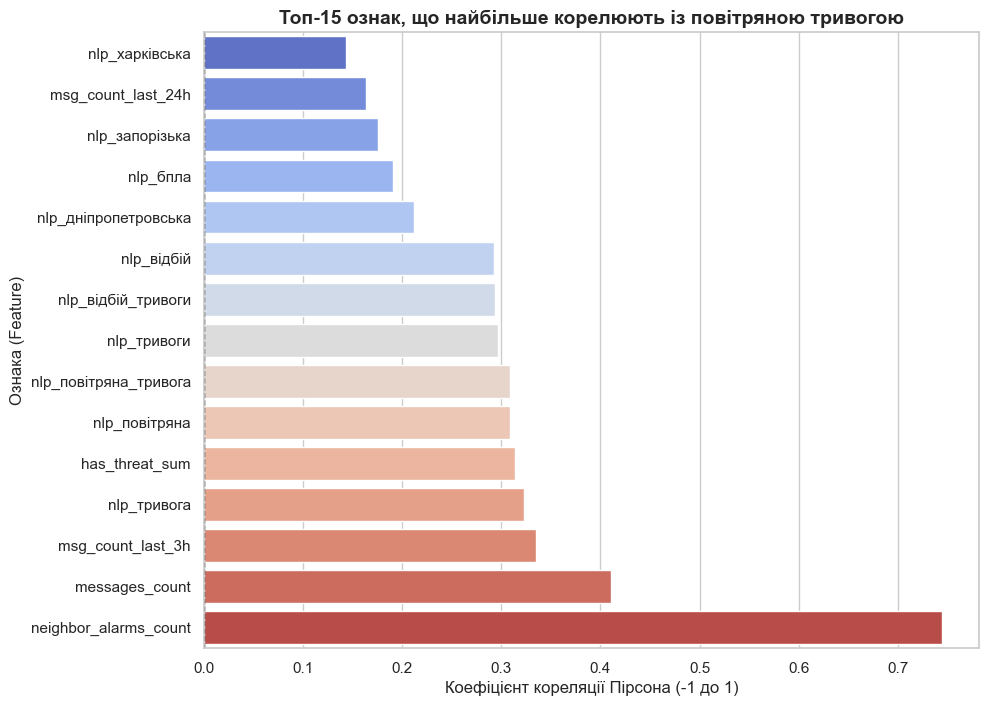

In [11]:
plt.figure(figsize=(10, 8))
# Обираємо тільки числові колонки для кореляції
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['alarm'].drop('alarm')

# Беремо топ-15 найсильніших кореляцій (за модулем)
top_corr = correlations.abs().sort_values(ascending=False).head(15).index
correlations_to_plot = correlations[top_corr].sort_values()

sns.barplot(x=correlations_to_plot.values, y=correlations_to_plot.index, palette="coolwarm")
plt.title("Топ-15 ознак, що найбільше корелюють із повітряною тривогою", fontsize=14, fontweight='bold')
plt.xlabel("Коефіцієнт кореляції Пірсона (-1 до 1)")
plt.ylabel("Ознака (Feature)")
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.show()

/var/folders/y4/w7fytwyn5_sc1g1w2sxgj15c0000gn/T/ipykernel_55048/4175260168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='neighbor_alarms_count', y='alarm', palette="Reds")


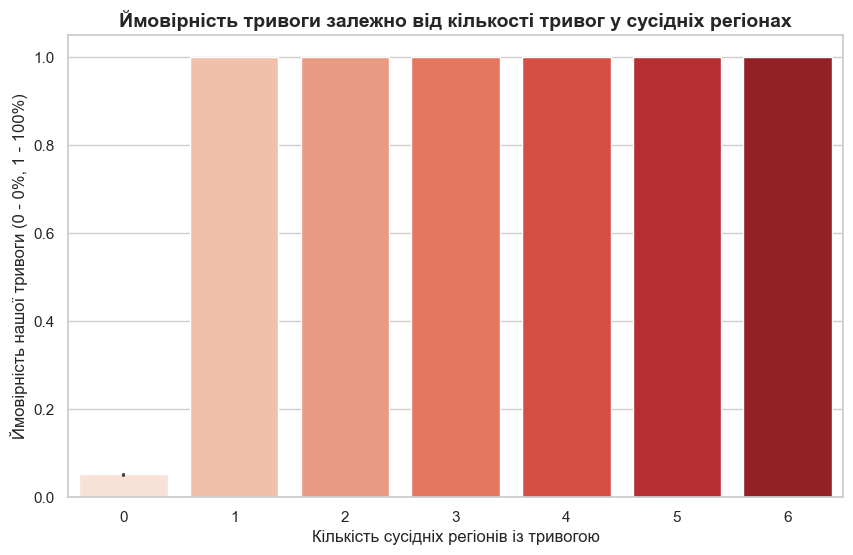

In [12]:
if 'neighbor_alarms_count' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='neighbor_alarms_count', y='alarm', palette="Reds")
    plt.title("Ймовірність тривоги залежно від кількості тривог у сусідніх регіонах", fontsize=14, fontweight='bold')
    plt.xlabel("Кількість сусідніх регіонів із тривогою")
    plt.ylabel("Ймовірність нашої тривоги (0 - 0%, 1 - 100%)")
    plt.show()

/var/folders/y4/w7fytwyn5_sc1g1w2sxgj15c0000gn/T/ipykernel_55048/3883170514.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['messages_count'] < df['messages_count'].quantile(0.95)],


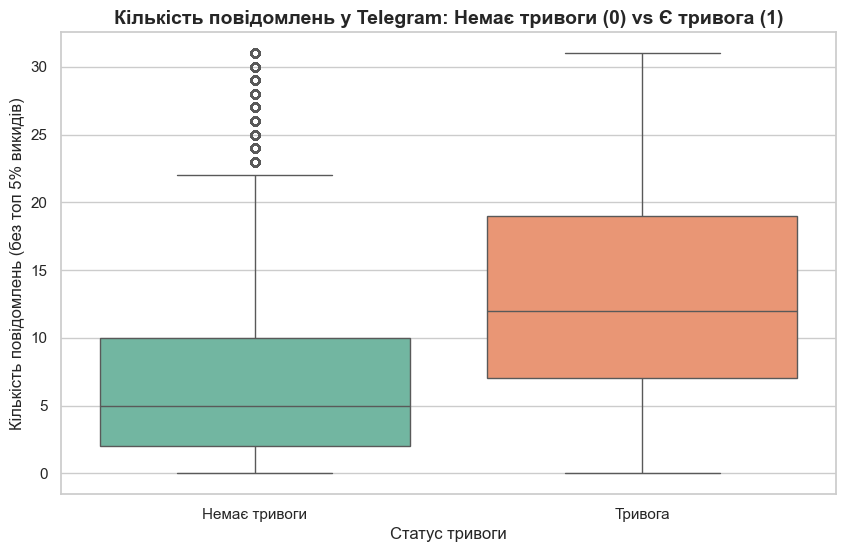

In [13]:
if 'messages_count' in df.columns:
    plt.figure(figsize=(10, 6))
    # Обмежуємо викиди (outliers), щоб графік був читабельним
    sns.boxplot(data=df[df['messages_count'] < df['messages_count'].quantile(0.95)], 
                x='alarm', y='messages_count', palette="Set2")
    plt.title("Кількість повідомлень у Telegram: Немає тривоги (0) vs Є тривога (1)", fontsize=14, fontweight='bold')
    plt.xlabel("Статус тривоги")
    plt.ylabel("Кількість повідомлень (без топ 5% викидів)")
    plt.xticks([0, 1], ['Немає тривоги', 'Тривога'])
    plt.show()

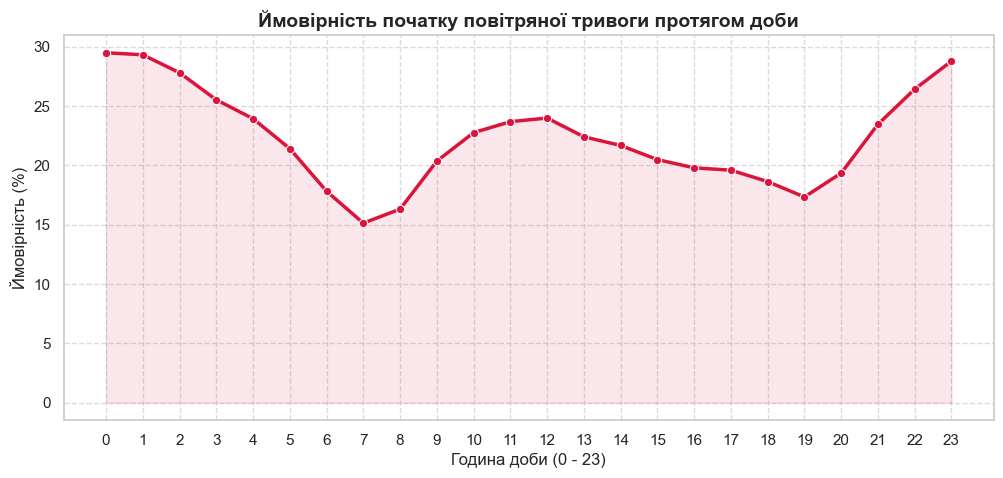

In [14]:
if 'hour_of_day' in df.columns:
    plt.figure(figsize=(12, 5))
    hourly_alarms = df.groupby('hour_of_day')['alarm'].mean() * 100
    sns.lineplot(x=hourly_alarms.index, y=hourly_alarms.values, marker="o", color="crimson", linewidth=2.5)
    plt.title("Ймовірність початку повітряної тривоги протягом доби", fontsize=14, fontweight='bold')
    plt.xlabel("Година доби (0 - 23)")
    plt.ylabel("Ймовірність (%)")
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.fill_between(hourly_alarms.index, hourly_alarms.values, color="crimson", alpha=0.1)
    plt.show()

<Figure size 1200x600 with 0 Axes>

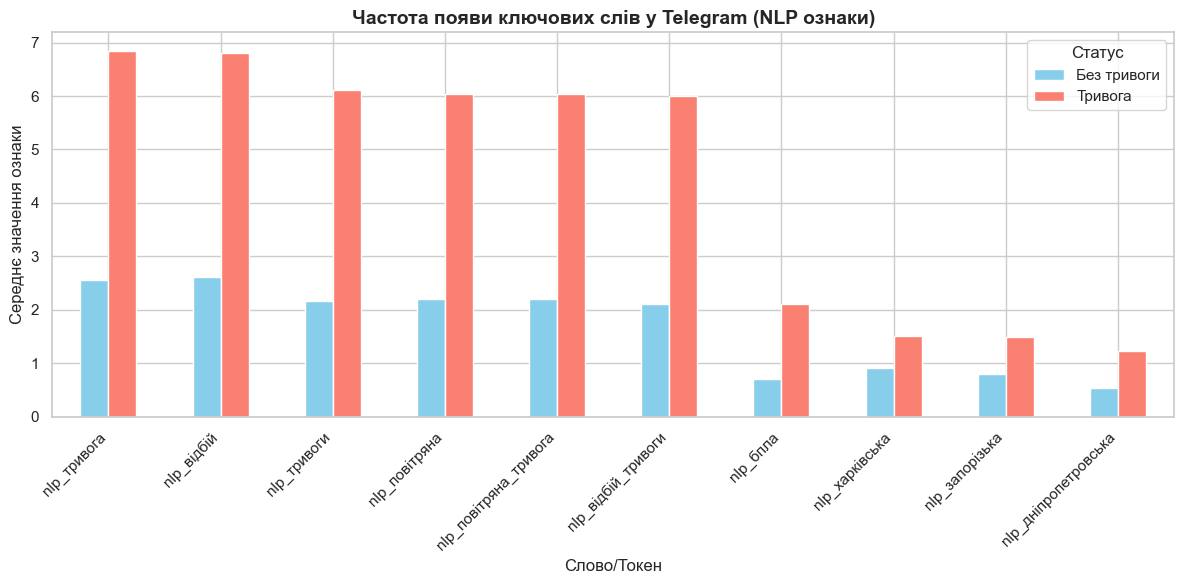

In [15]:
nlp_cols = [col for col in df.columns if col.startswith('nlp_')]
if nlp_cols:
    plt.figure(figsize=(12, 6))
    # Знайдемо середнє значення використання слова для класів alarm=0 та alarm=1
    nlp_means = df.groupby('alarm')[nlp_cols].mean().T
    nlp_means.columns = ['Без тривоги', 'Тривога']
    
    # Беремо топ-10 слів, які найчастіше з'являються під час тривоги
    top_nlp = nlp_means.sort_values(by='Тривога', ascending=False).head(10)
    
    top_nlp.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'])
    plt.title("Частота появи ключових слів у Telegram (NLP ознаки)", fontsize=14, fontweight='bold')
    plt.xlabel("Слово/Токен")
    plt.ylabel("Середнє значення ознаки")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Статус")
    plt.tight_layout()
    plt.show()